# 03 - Baseline Classico (Trilha A) + Objetivo Especifico 1

Objetivo: usar as features agregadas por clipe (media/desvio/percentis de EAR, MAR, yaw, pitch, roll, gaze horizontal/vertical, taxa de deteccao de rosto) para treinar classificadores classicos (RandomForest, XGBoost, SVM) com `GridSearchCV`, comparando estrategias de balanceamento de classes.

Este notebook responde diretamente:
- **Objetivo Geral** (Secao 2 do plano): comparacao com baseline trivial (macro-F1/kappa).
- **Objetivo Especifico 1**: ranking de importancia de features por rotulo - atencao especial as features de **gaze/iris** (`gaze_h`, `gaze_v`, `gaze_offset`), dado que Sugihdharma & Bachtiar (2023, SAE-CNN, Secao 3 do plano) reportaram a maior acuracia da literatura revisada usando **apenas** marcos oculares e gaze; verificar se esse sinal tambem se destaca aqui reforca (ou nao) essa hipotese com um protocolo de avaliacao mais completo (macro-F1/kappa, nao so acuracia).

Pre-requisito: `02_preprocessamento_landmarks.ipynb` executado (arquivos `.parquet` em `datasets/DAiSEE/features/`).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score, balanced_accuracy_score,
    classification_report, confusion_matrix
)
from sklearn.dummy import DummyClassifier
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
ROOT = Path.cwd().parent
FEATURES_DIR = ROOT / "datasets" / "DAiSEE" / "features"
TARGET = "Engagement"  # trocar para Boredom/Confusion/Frustration para repetir a analise (Objetivo 1)

In [2]:
def desdobrar_roll(s):
    """Corrige a descontinuidade circular do angulo de roll.

    O roll vindo do solvePnP/Rodrigues fica em [-180, 180] e, para uma cabeca ereta,
    concentra-se junto de +-180 (99,4% dos quadros). Assim, +179 e -179 - que distam
    2 graus na realidade - aparecem como 358 graus de diferenca, inflando media/desvio.
    Isso corrompia `roll_std` em 25,4% dos clipes (media 35,3 contra 1,8 do desvio
    circular correto). Mapear para [0, 360) desloca o corte para 0 e torna a serie
    continua na regiao onde os dados de fato estao.
    """
    return s % 360


def load_and_aggregate(split_name):
    df = pd.read_parquet(FEATURES_DIR / f"{split_name}_frame_features.parquet")
    df["roll"] = desdobrar_roll(df["roll"])
    feat_cols = ["ear", "mar", "yaw", "pitch", "roll", "gaze_h", "gaze_v", "gaze_offset"]

    agg_funcs = ["mean", "std", "min", "max"]
    grouped = df.groupby("ClipID")

    agg = grouped[feat_cols].agg(agg_funcs)
    agg.columns = ["_".join(c) for c in agg.columns]
    face_rate = grouped["face_detected"].mean().rename("face_detection_rate")
    labels = grouped[["Boredom", "Engagement", "Confusion", "Frustration"]].first()

    out = agg.join(face_rate).join(labels).reset_index()
    return out

train_agg = load_and_aggregate("train")
val_agg = load_and_aggregate("validation")
test_agg = load_and_aggregate("test")

feature_cols = [c for c in train_agg.columns if c not in ["ClipID", "Boredom", "Engagement", "Confusion", "Frustration"]]
print("Numero de features:", len(feature_cols))
print("Verificacao do roll corrigido - mediana de roll_std:", round(train_agg["roll_std"].median(), 2),
      "| media:", round(train_agg["roll_std"].mean(), 2))
train_agg.head()

Numero de features: 33
Verificacao do roll corrigido - mediana de roll_std: 1.04 | media: 1.83


,ClipID,ear_mean,ear_std,ear_min,ear_max,mar_mean,mar_std,mar_min,mar_max,yaw_mean,...,gaze_v_max,gaze_offset_mean,gaze_offset_std,gaze_offset_min,gaze_offset_max,face_detection_rate,Boredom,Engagement,Confusion,Frustration
0,1100011002.avi,0.335708,0.026918,0.251913,0.365131,0.578915,0.088647,0.439951,0.704684,1.354313,...,0.465461,0.141145,0.045472,0.083461,0.240507,1.0,0,2,0,0
1,1100011003.avi,0.355453,0.010167,0.336820,0.373677,0.621326,0.042973,0.530869,0.699950,-5.410013,...,0.393826,0.149207,0.027251,0.114092,0.214425,1.0,0,2,0,0
2,1100011004.avi,0.348376,0.041381,0.176531,0.368069,0.633589,0.030742,0.590713,0.691540,-4.976256,...,0.397678,0.143887,0.032785,0.104403,0.252502,1.0,0,3,0,0
3,1100011005.avi,0.352184,0.021892,0.265700,0.371798,0.669193,0.028532,0.620763,0.718548,-1.798738,...,0.418224,0.128959,0.022657,0.096425,0.182363,1.0,0,3,0,0
4,1100011006.avi,0.324309,0.021219,0.268791,0.359091,0.573466,0.065463,0.430031,0.696431,2.739818,...,0.566142,0.124679,0.054629,0.036036,0.276640,1.0,0,3,0,0


In [3]:
X_train, y_train = train_agg[feature_cols].fillna(0), train_agg[TARGET]
X_val, y_val = val_agg[feature_cols].fillna(0), val_agg[TARGET]
X_test, y_test = test_agg[feature_cols].fillna(0), test_agg[TARGET]

print("Distribuicao y_train:", y_train.value_counts(normalize=True).round(3).to_dict())

Distribuicao y_train: {2: 0.51, 3: 0.442, 1: 0.041, 0: 0.007}


## Metricas completas obrigatorias (ver Secao 6 do plano)

In [4]:
def full_report(y_true, y_pred, nome_modelo):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    kappa = cohen_kappa_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    print(f"\n===== {nome_modelo} =====")
    print(f"Acuracia: {acc:.4f} | Macro-F1: {macro_f1:.4f} | Kappa: {kappa:.4f} | Balanced Acc: {bal_acc:.4f}")
    print(classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de Confusao - {nome_modelo}")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.show()

    return {"modelo": nome_modelo, "acc": acc, "macro_f1": macro_f1, "kappa": kappa, "balanced_acc": bal_acc}

## Baseline trivial (para validar a hipotese, Secao 2 e 10 do plano)


===== Baseline trivial (classe majoritaria) =====
Acuracia: 0.5183 | Macro-F1: 0.1707 | Kappa: 0.0000 | Balanced Acc: 0.2500
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.00      0.00      0.00        81
           2       0.52      1.00      0.68       849
           3       0.00      0.00      0.00       704

    accuracy                           0.52      1638
   macro avg       0.13      0.25      0.17      1638
weighted avg       0.27      0.52      0.35      1638



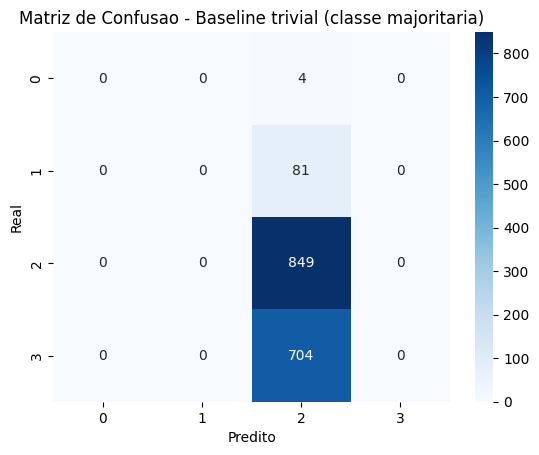

In [5]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
results = [full_report(y_test, dummy.predict(X_test), "Baseline trivial (classe majoritaria)")]

## Estrategia 1: sem tratamento de desbalanceamento

Melhores parametros: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 400}

===== RandomForest (sem balanceamento) =====
Acuracia: 0.5153 | Macro-F1: 0.2466 | Kappa: 0.0407 | Balanced Acc: 0.2612
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.00      0.00      0.00        81
           2       0.53      0.75      0.62       849
           3       0.48      0.30      0.37       704

    accuracy                           0.52      1638
   macro avg       0.25      0.26      0.25      1638
weighted avg       0.48      0.52      0.48      1638



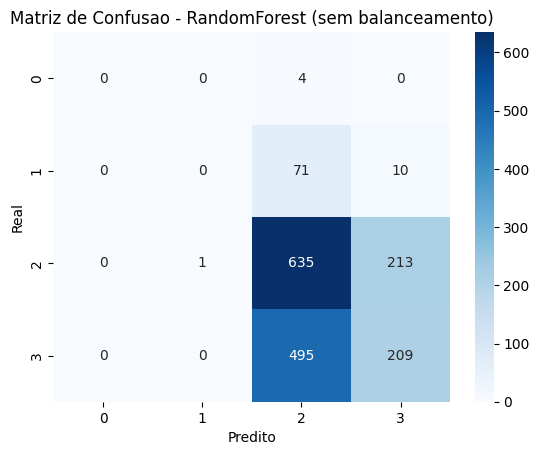

In [6]:
rf_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_param_grid, scoring="f1_macro", cv=cv, n_jobs=-1,
)
rf_grid.fit(X_train, y_train)
print("Melhores parametros:", rf_grid.best_params_)
results.append(full_report(y_test, rf_grid.best_estimator_.predict(X_test), "RandomForest (sem balanceamento)"))

## Estrategia 2: class_weight='balanced'


===== RandomForest (class_weight=balanced) =====
Acuracia: 0.5269 | Macro-F1: 0.3824 | Kappa: 0.1108 | Balanced Acc: 0.3844
              precision    recall  f1-score   support

           0       0.20      0.25      0.22         4
           1       0.29      0.22      0.25        81
           2       0.55      0.65      0.60       849
           3       0.51      0.42      0.46       704

    accuracy                           0.53      1638
   macro avg       0.39      0.38      0.38      1638
weighted avg       0.52      0.53      0.52      1638



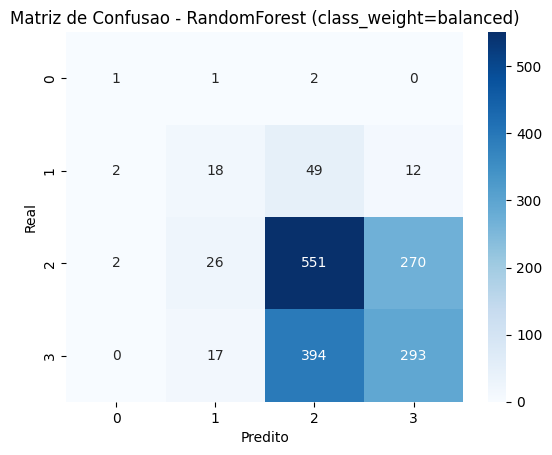

In [7]:
rf_balanced_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    rf_param_grid, scoring="f1_macro", cv=cv, n_jobs=-1,
)
rf_balanced_grid.fit(X_train, y_train)
best_rf = rf_balanced_grid.best_estimator_
results.append(full_report(y_test, best_rf.predict(X_test), "RandomForest (class_weight=balanced)"))

## Estrategia 3: oversampling com SMOTE (apenas no Train, sem vazamento)

Distribuicao apos SMOTE: {2: 2474, 3: 2474, 1: 2474, 0: 2474}



===== RandomForest + SMOTE =====
Acuracia: 0.4915 | Macro-F1: 0.2821 | Kappa: 0.0792 | Balanced Acc: 0.2892
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.09      0.16      0.12        81
           2       0.55      0.63      0.58       849
           3       0.50      0.37      0.43       704

    accuracy                           0.49      1638
   macro avg       0.29      0.29      0.28      1638
weighted avg       0.50      0.49      0.49      1638



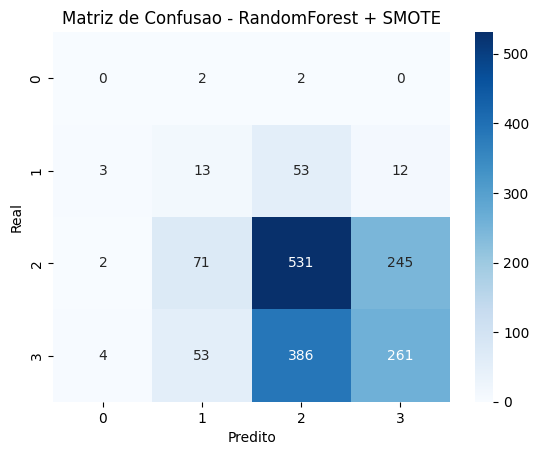

In [8]:
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=3)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("Distribuicao apos SMOTE:", pd.Series(y_train_sm).value_counts().to_dict())

rf_smote = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=400)
rf_smote.fit(X_train_sm, y_train_sm)
results.append(full_report(y_test, rf_smote.predict(X_test), "RandomForest + SMOTE"))

## XGBoost (com scale/peso por classe) e SVM para comparacao

Peso por classe (inverso da frequencia): {2: 0.045, 3: 0.052, 1: 0.551, 0: 3.353}



===== XGBoost (sample_weight balanceado) =====
Acuracia: 0.4829 | Macro-F1: 0.3456 | Kappa: 0.0517 | Balanced Acc: 0.3699
              precision    recall  f1-score   support

           0       0.14      0.25      0.18         4
           1       0.20      0.26      0.23        81
           2       0.53      0.59      0.56       849
           3       0.46      0.38      0.41       704

    accuracy                           0.48      1638
   macro avg       0.33      0.37      0.35      1638
weighted avg       0.48      0.48      0.48      1638



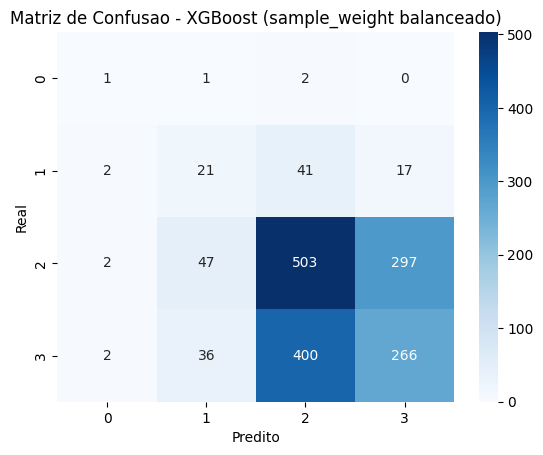


===== SVM (class_weight=balanced) =====
Acuracia: 0.3620 | Macro-F1: 0.2081 | Kappa: 0.0344 | Balanced Acc: 0.2449
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.11      0.17      0.14        81
           2       0.50      0.08      0.13       849
           3       0.46      0.73      0.56       704

    accuracy                           0.36      1638
   macro avg       0.27      0.24      0.21      1638
weighted avg       0.46      0.36      0.32      1638



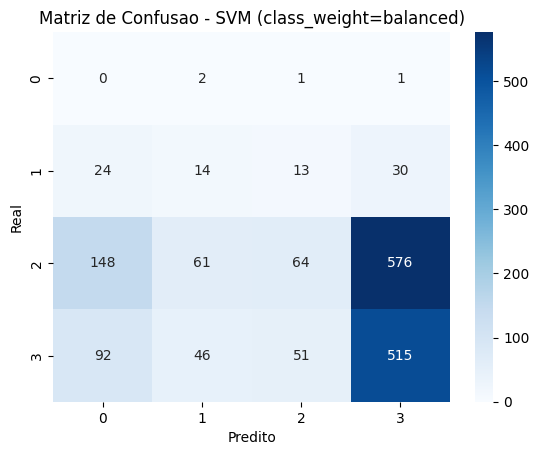

In [9]:
# Pesos por amostra = inverso da frequencia da classe (normalizado), para o XGBoost.
# (Correcao: `.rpow(-1)` calcularia (-1)**proporcao -> NaN; o correto e o inverso da frequencia.)
freq = y_train.value_counts(normalize=True)
inv_freq = (1.0 / freq) / (1.0 / freq).sum() * len(freq)
sample_weights = y_train.map(inv_freq)
print("Peso por classe (inverso da frequencia):", inv_freq.round(3).to_dict())

xgb_model = xgb.XGBClassifier(
    random_state=RANDOM_STATE, n_estimators=400, max_depth=6, learning_rate=0.05,
    eval_metric="mlogloss",
)
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
results.append(full_report(y_test, xgb_model.predict(X_test), "XGBoost (sample_weight balanceado)"))

svm_model = SVC(kernel="rbf", class_weight="balanced", random_state=RANDOM_STATE, probability=True)
svm_model.fit(X_train, y_train)
results.append(full_report(y_test, svm_model.predict(X_test), "SVM (class_weight=balanced)"))

## Objetivo Especifico 1 - Ranking de importancia de features

Repetir para cada rotulo (Boredom, Engagement, Confusion, Frustration) e validar estabilidade do top-5 via CV (ver criterio de mensurabilidade na Secao 2 do plano).

Top-10 features para Engagement:
ear_mean           0.081320
ear_min            0.055127
gaze_v_std         0.044654
ear_std            0.041548
gaze_h_std         0.038042
ear_max            0.037954
roll_std           0.035508
gaze_h_min         0.035183
gaze_offset_std    0.035092
gaze_v_max         0.033648
dtype: float64


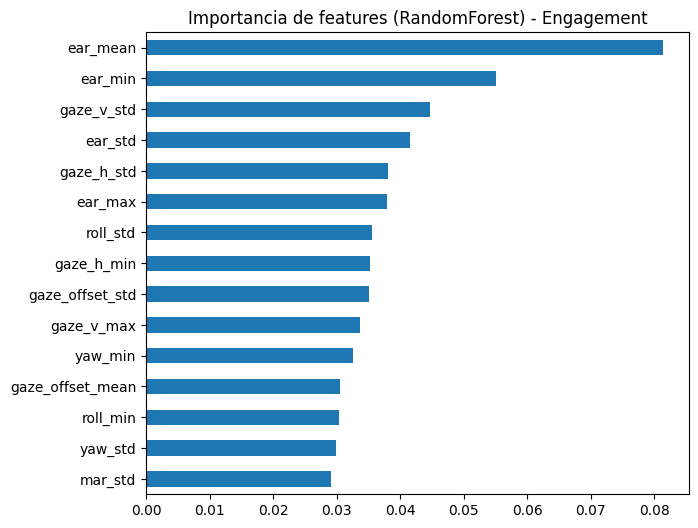

In [10]:
importances = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(f"Top-10 features para {TARGET}:")
print(importances.head(10))

importances.head(15).plot(kind="barh", figsize=(7, 6))
plt.title(f"Importancia de features (RandomForest) - {TARGET}")
plt.gca().invert_yaxis()
plt.show()

In [11]:
# Estabilidade do ranking via K-Fold (top-5 deve se repetir em >= 4/5 folds - criterio do Objetivo 1)
from collections import Counter

top5_per_fold = []
for train_idx, _ in cv.split(X_train, y_train):
    rf_fold = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200, class_weight="balanced")
    rf_fold.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    top5 = pd.Series(rf_fold.feature_importances_, index=feature_cols).sort_values(ascending=False).head(5).index.tolist()
    top5_per_fold.append(tuple(top5))

feature_stability = Counter([f for fold in top5_per_fold for f in fold])
print("Frequencia de cada feature no top-5 (max=5 folds):")
print(pd.Series(feature_stability).sort_values(ascending=False))

Frequencia de cada feature no top-5 (max=5 folds):
ear_mean           5
ear_min            5
gaze_v_std         4
ear_std            4
roll_std           2
ear_max            2
gaze_h_min         1
gaze_h_std         1
gaze_offset_std    1
dtype: int64


## Consolidacao dos resultados desta trilha

In [12]:
results_df = pd.DataFrame(results)
results_df.to_csv(FEATURES_DIR / "resultados_trilha_a_classico.csv", index=False)
display(results_df)

# --- Persistir predicoes do melhor modelo desta trilha, para o Notebook 05 ---
# (bootstrap CI, versao binaria Engajado x Desengajado e curva ROC precisam das
#  predicoes e probabilidades reais no conjunto de teste)
candidatos = {
    "RandomForest (sem balanceamento)": rf_grid.best_estimator_,
    "RandomForest (class_weight=balanced)": best_rf,
    "RandomForest + SMOTE": rf_smote,
    "XGBoost (sample_weight balanceado)": xgb_model,
    "SVM (class_weight=balanced)": svm_model,
}
# Escolhe o melhor ENTRE OS MODELOS TREINADOS (exclui o baseline trivial, que nao e candidato)
treinados = results_df[results_df["modelo"].isin(candidatos)]
melhor_nome = treinados.loc[treinados["macro_f1"].idxmax(), "modelo"]
melhor_obj = candidatos[melhor_nome]
print("Melhor modelo da Trilha A (por macro-F1):", melhor_nome)

proba_test = melhor_obj.predict_proba(X_test)
pred_test = melhor_obj.predict(X_test)

pred_df = pd.DataFrame({
    "ClipID": test_agg["ClipID"].values,
    "y_true": y_test.values,
    "y_pred": pred_test,
})
for k in range(proba_test.shape[1]):
    pred_df[f"proba_{melhor_obj.classes_[k]}"] = proba_test[:, k]
pred_df.to_csv(FEATURES_DIR / "predicoes_teste_trilha_a.csv", index=False)

# Baseline trivial tambem, para o teste de sobreposicao de IC no Notebook 05
pd.DataFrame({
    "ClipID": test_agg["ClipID"].values,
    "y_true": y_test.values,
    "y_pred": dummy.predict(X_test),
}).to_csv(FEATURES_DIR / "predicoes_teste_baseline.csv", index=False)

# Importancias de features (Objetivo Especifico 1) para reuso no Notebook 05/docx
importances.to_csv(FEATURES_DIR / "importancias_features_engagement.csv", header=["importancia"])
pd.Series(feature_stability).sort_values(ascending=False).to_csv(
    FEATURES_DIR / "estabilidade_top5_features.csv", header=["freq_em_5_folds"]
)

# Taxa de deteccao de rosto por split (limitacao a reportar no docx)
taxa_deteccao = {
    "train": float(train_agg["face_detection_rate"].mean()),
    "validation": float(val_agg["face_detection_rate"].mean()),
    "test": float(test_agg["face_detection_rate"].mean()),
}
print("Taxa media de deteccao de rosto por split:", {k: round(v, 4) for k, v in taxa_deteccao.items()})
pd.DataFrame([taxa_deteccao]).to_csv(FEATURES_DIR / "taxa_deteccao_rosto.csv", index=False)

# Numero de clipes efetivamente usados por split
n_clipes = {"train": len(train_agg), "validation": len(val_agg), "test": len(test_agg)}
print("Clipes por split:", n_clipes)
pd.DataFrame([n_clipes]).to_csv(FEATURES_DIR / "n_clipes_por_split.csv", index=False)

print("Predicoes e importancias salvas em", FEATURES_DIR)
results_df

,modelo,acc,macro_f1,kappa,balanced_acc
0,Baseline trivial (classe majoritaria),0.518315,0.170688,0.000000,0.250000
1,RandomForest (sem balanceamento),0.515263,0.246566,0.040728,0.261203
2,RandomForest (class_weight=balanced),0.526862,0.382358,0.110779,0.384354
3,RandomForest + SMOTE,0.491453,0.282137,0.079222,0.289169
4,XGBoost (sample_weight balanceado),0.482906,0.345600,0.051708,0.369890
5,SVM (class_weight=balanced),0.362027,0.208052,0.034359,0.244939


Melhor modelo da Trilha A (por macro-F1): RandomForest (class_weight=balanced)
Taxa media de deteccao de rosto por split: {'train': 0.9999, 'validation': 0.9999, 'test': 0.9997}
Clipes por split: {'train': 4851, 'validation': 1429, 'test': 1638}
Predicoes e importancias salvas em C:\Users\paulo\Documents\Mestrado\Projetos de Pesquisa\Engajamento_EAD\datasets\DAiSEE\features


,modelo,acc,macro_f1,kappa,balanced_acc
0,Baseline trivial (classe majoritaria),0.518315,0.170688,0.000000,0.250000
1,RandomForest (sem balanceamento),0.515263,0.246566,0.040728,0.261203
2,RandomForest (class_weight=balanced),0.526862,0.382358,0.110779,0.384354
3,RandomForest + SMOTE,0.491453,0.282137,0.079222,0.289169
4,XGBoost (sample_weight balanceado),0.482906,0.345600,0.051708,0.369890
5,SVM (class_weight=balanced),0.362027,0.208052,0.034359,0.244939


## Checklist de saida
- [ ] Baseline trivial e ao menos 4 variantes de balanceamento comparadas com metricas completas
- [ ] Ranking de importancia de features gerado e estabilidade avaliada (Objetivo Especifico 1)
- [ ] `resultados_trilha_a_classico.csv` salvo para consolidacao no Notebook 05

Proximo passo: `04_modelo_temporal_dl.ipynb`.